## Submission 3. Bias

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
### Run this for data export to Dandi purpose only.
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().start_export(**paper_key, analysis_id="change_of_mind_behavior")

[2026-04-21 15:24:31,459][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[15:24:35][INFO] Spyglass: Resuming {'export_id': 90}


### Start here

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
from scipy import stats
import starbars

cmap = mpl.colormaps['cool']

In [4]:
from spyglass.shijiegu.behavior import get_transition_matrix_animal, return_neighbor_nonneighor
from spyglass.shijiegu.changeOfMind_triggered import find_triggered_transition_animal, seq1,seq2,rev1,rev2,rev3
from spyglass.shijiegu.changeOfMind_byTransition import find_COM_transitions

from spyglass.shijiegu.Analysis_SGU import ChangeofMind
from spyglass.common.common_position import IntervalPositionInfo, RawPosition, IntervalLinearizedPosition

[15:24:46][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:24:48][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:24:49][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:24:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackG

In [5]:
list_of_days_animals = {}
seq_animals = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220415','20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = seq2

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']
seq_animals[animal] = rev2

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = seq2

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = seq2

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']
seq_animals[animal] = rev2

In [11]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure1' #replace with your path

for animal in list_of_days_animals.keys():

    days_to_plot = list_of_days_animals[animal]
        
    print(animal)
    
    seq_maps = {}
    for d in days_to_plot:
        seq_maps[d] = seq_animals[animal]
        
    (retro_wouldhave,transition_wouldhave, transition,
     correct, correct_rand, correct_wouldhave,
     recent, recent_wouldhave) = find_triggered_transition_animal(animal[:5], days_to_plot, seq_maps, proportion = 0.1)

    file_path = f"{output_folder}/correctness_{animal}.pickle"

    data = {}
    data["retro_wouldhave"] = retro_wouldhave
    data["transition_wouldhave"] = transition_wouldhave
    data["transition"] = transition
    data["correct"] = correct
    data["correct_rand"] =  correct_rand
    data["correct_wouldhave"] = correct_wouldhave
    data["recent"] =  recent
    data["recent_wouldhave"] = recent_wouldhave
    data["list_of_days"] = list_of_days_animals
    data["seq"] = seq_animals
    
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved to {file_path}")

[15:31:36][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:31:36][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


molly
currently investigating:
02_SeqSession1
pos 1 valid times
currently investigating:
04_Seq2Session1
pos 3 valid times
currently investigating:
06_Seq2Session2
pos 5 valid times
currently investigating:
08_Seq2Session3
pos 7 valid times
currently investigating:
02_Seq2Session1
pos 1 valid times
currently investigating:
04_Seq2Session2
pos 3 valid times
currently investigating:
06_Seq2Session3
pos 5 valid times
currently investigating:
08_Seq2Session4
pos 7 valid times
currently investigating:
10_Seq2Session5
pos 9 valid times
currently investigating:
02_Seq2Session1
pos 1 valid times
currently investigating:
04_Seq2Session2
pos 3 valid times
currently investigating:
06_Seq2Session3
pos 5 valid times
currently investigating:
08_Seq2Session4
pos 7 valid times
currently investigating:
10_Seq2Session5
pos 9 valid times
currently investigating:
02_Seq2Session1
pos 1 valid times
currently investigating:
04_Seq2Session2
pos 3 valid times
currently investigating:
06_Seq2Session3
pos 5 vali

### A. Pre-post change-of-mind correct rate

In [13]:
from matplotlib.colors import Normalize
import matplotlib as mpl
import starbars
cmap = mpl.colormaps['cool']

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_molly.pickle
p_value 0.009032277540098433
p_value 0.6892135989823185
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_eliot.pickle
p_value 0.010084336972062442
p_value 0.27670509739406507
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_julio.pickle
p_value 0.0001325172227451306
p_value 0.8868490277174362
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_klein.pickle
p_value 0.0012430266858741653
p_value 0.6696318179476272
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_lewis.pickle
p_value 4.7172742445930115e-05
p_value 0.1049150652893935
4.7299999999999995 0.03
4.7299999999999995 0.03
4.7299999999999995 0.03
4.7299999999999995 0.03
4.7299999999999995 0.03


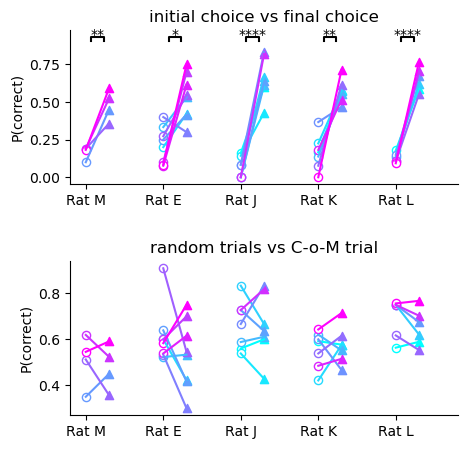

In [14]:
fig,axes = plt.subplots(2,1,figsize = (5,5))
plt.subplots_adjust(wspace=0.8, hspace=0.5)

data_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis",]

annotations = []
annotations_rand = []
for animal in animals:
    
    ### load data
    file_path = f"{output_folder}/correctness_{animal}.pickle"

    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")

    correct = data["correct"]
    correct_rand = data["correct_rand"]
    correct_wouldhave = data["correct_wouldhave"]
    dates_to_plot = list(data["correct"].keys()) #, post = data["pre"], data["post"]

    norm = Normalize(vmin=0, vmax=len(dates_to_plot)-1)

    rates = []
    rates_wouldhave = []
    rates_rand = []
    for d_ind in range(len(dates_to_plot)):
        d = dates_to_plot[d_ind]
        correct_day = correct[d]
        correct_wouldhave_day = correct_wouldhave[d]
        correct_rand_day = correct_rand[d]

        if len(correct_day) <= 10:
            continue
    
        # rate
        rate = np.sum(correct_day)/len(correct_day)
        rate_wouldhave = np.sum(correct_wouldhave_day)/len(correct_wouldhave_day)
        rate_rand = np.sum(correct_rand_day)/len(correct_rand_day) 
        
        rates.append(rate)
        rates_wouldhave.append(rate_wouldhave)
        rates_rand.append(rate_rand)

        axe = axes[0]

        dot_size = 35
        axe.scatter(np.zeros_like(rate_wouldhave) + animal_ind, rate_wouldhave,
                    edgecolor = cmap(norm(d_ind)), facecolor = 'white', s = dot_size, marker = "o")
        axe.scatter(np.zeros_like(rate) + animal_ind + 0.3, rate,
                    edgecolor = cmap(norm(d_ind)), facecolor = cmap(norm(d_ind)), s = dot_size, marker = "^")
        axe.plot(np.array([0,0.3]) + animal_ind,[rate_wouldhave, rate],color = cmap(norm(d_ind)))

        axe = axes[1]
        axe.scatter(np.zeros_like(rate_rand) + animal_ind, rate_rand,
                    edgecolor = cmap(norm(d_ind)), facecolor = 'white', s = dot_size, marker = "o")
        axe.scatter(np.zeros_like(rate) + animal_ind + 0.3, rate,
                    edgecolor = cmap(norm(d_ind)), facecolor = cmap(norm(d_ind)), s = dot_size, marker = "^")
        axe.plot(np.array([0,0.3]) + animal_ind,[rate_rand, rate],color = cmap(norm(d_ind)))
        

    #### add stats
    t_statistic, p_value = stats.ttest_rel(rates, rates_wouldhave)
    print("p_value", p_value)
    if p_value < 0.05:
        annotations.append((animal_ind, animal_ind + 0.3, np.round(p_value, 4)))
        
    t_statistic, p_value = stats.ttest_rel(rates, rates_rand)
    print("p_value", p_value)
    if p_value < 0.05:
        annotations_rand.append((animal_ind, animal_ind + 0.3, np.round(p_value, 4)))
        
    ########
    animal_ind += 1

if len(annotations) > 0:
    starbars.draw_annotation(annotations,ax = axes[0])
if len(annotations_rand) > 0:
    starbars.draw_annotation(annotations_rand,ax = axes[1])

axes[0].set_xticks(np.arange(len(animals)));
axes[0].set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
axes[0].set_xlim([-0.2,len(animals) - 0.2]);
axes[0].set_title("initial choice vs final choice")
axes[0].set_ylabel("P(correct)")
axes[0].spines[['right', 'top']].set_visible(False)

axes[1].set_xticks(np.arange(len(animals)));
axes[1].set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
axes[1].set_xlim([-0.2,len(animals) -0.2]);
axes[1].set_title("random trials vs C-o-M trial")
axes[1].set_ylabel("P(correct)")
axes[1].spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1/correcting"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png")   

### B. Pre-post change of mind bias

In [15]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'
data_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'

animals = ["molly","eliot","julio","klein","lewis",]
success_animal = {}

for animal in animals:
    
    ### load data
    file_path = f"{output_folder}/correctness_{animal}.pickle"

    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")

    # just to make sure all the panels use the same data
    dates_to_plot = list(data["correct"].keys()) #, post = data["pre"], data["post"]

    transition_final, transition_initial = find_COM_transitions(animal, dates_to_plot, proportion_threshold = 0.1)

    file_path = f"{data_folder}/correctness_bias_{animal}.pickle"

    data = {}
    data["transition_final"] = transition_final
    data["transition_initial"] = transition_initial
    
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved to {file_path}")
    success_animal[animal] = True
    
    

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_molly.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/correctness_bias_molly.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_eliot.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/correctness_bias_eliot.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_julio.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/correctness_bias_julio.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_klein.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/correctness_bias_klein.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_lewis.pickle
Data successfully pickled 

In [16]:
len(transition_final)

6

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_bias_molly.pickle
p_value 0.13635072763265302
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_bias_eliot.pickle
p_value 0.0014940839640986549
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_bias_julio.pickle
p_value 0.0009481397310321281
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_bias_klein.pickle
p_value 0.0034620842396471795
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/correctness_bias_lewis.pickle
p_value 0.005526166994830973
5.0 0.03
5.0 0.03
5.0 0.03
5.0 0.03


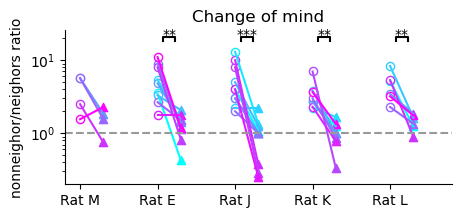

In [18]:
fig,axes = plt.subplots(1,1,figsize = (5,2))
plt.subplots_adjust(wspace=0.8, hspace=0.5)

data_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis",]

annotations = []
for animal in animals:
    
    ### load data
    file_path = f"{data_folder}/correctness_bias_{animal}.pickle"

    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        transition_final = data["transition_final"]
        transition_initial = data["transition_initial"]
        print(f"Data successfully loaded from {file_path}")

    # just to make sure all the panels use the same data
    dates_to_plot = np.arange(len(transition_final)) #, post = data["pre"], data["post"]

    norm = Normalize(vmin=0, vmax=len(dates_to_plot)-1)

    transition_final = np.stack([d for d in transition_final], axis = 2)
    transition_initial = np.stack([d for d in transition_initial], axis = 2)
    P_neighors_init, P_nonneighors_init = return_neighbor_nonneighor(transition_initial)
    P_neighors_final, P_nonneighors_final = return_neighbor_nonneighor(transition_final)

    ratio_init_all = []
    ratio_final_all = []
    for ind in range(len(dates_to_plot)):
        if P_neighors_init[ind] == 0 or P_neighors_final[ind] == 0:
            continue
        ratio_init = P_nonneighors_init[ind]/P_neighors_init[ind]
        ratio_final = P_nonneighors_final[ind]/P_neighors_final[ind]

        dot_size = 35
        axes.scatter(np.zeros_like(ratio_init) + animal_ind, ratio_init,
                     edgecolor = cmap(norm(ind)), facecolor = 'white', s = dot_size, marker = "o")
        axes.scatter(np.zeros_like(ratio_final) + animal_ind+0.3, ratio_final,
                     edgecolor = cmap(norm(ind)), facecolor = cmap(norm(ind)), s = dot_size, marker = "^")
        axes.plot(np.array([0,0.3]) + animal_ind,[ratio_init, ratio_final],color = cmap(norm(ind)))

        ratio_init_all.append(ratio_init)
        ratio_final_all.append(ratio_final)

    #### add stats
    t_statistic, p_value = stats.ttest_rel(np.log(ratio_init_all), np.log(ratio_final_all))
    print("p_value",p_value)
    if p_value < 0.05:
        annotations.append((animal_ind, animal_ind + 0.3, np.round(p_value, 4)))
    ########
    
    animal_ind += 1

# log scale
axes.set_yscale('log')

axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
axes.set_xticks(np.arange(len(animals)));
axes.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
axes.set_xlim([-0.2,len(animals) - 0.2]);
axes.set_title("Change of mind")
axes.set_ylabel("nonneighor/neighors ratio")
axes.spines[['right', 'top']].set_visible(False)

starbars.draw_annotation(annotations)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1/correcting_bias"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png")   

    

### End here

In [27]:
### Run below for data export to Dandi purpose only.

In [19]:
ExportSelection().stop_export(**paper_key, analysis_id="change_of_mind_behavior")

In [26]:


ExportSelection().list_file_paths(paper_key)



[]

In [22]:
ExportSelection() & {"paper_id":"Gu2026"}

export_id,paper_id,analysis_id,spyglass_version,time
90,Gu2026,change_of_mind_behavior,0.5.4a2,2026-04-21 10:22:27


In [23]:
ExportSelection().show_all_tables(**paper_key)

[FreeTable(`common_task`.`task`)
 *task_name     task_descripti task_type     task_subtype  
 +------------+ +------------+ +-----------+ +------------+
 maze           maze           None          None          
 maze session   maze session   None          None          
 Sleep          The animal sle                             
 sleep session  sleep session  None          None          
  (Total: 4),
 FreeTable(`common_subject`.`subject`)
 *subject_id    age      description    genotype      sex     species       
 +------------+ +------+ +------------+ +-----------+ +-----+ +------------+
 eliot          None     Long Evans Rat Wild Type     M       Rattus norvegi
 julio          None     Long Evans Rat Wild Type     M       Rattus norvegi
 klein          None     Long Evans Rat Wild Type     M       Rattus norvegi
 lewis          None     Long Evans Rat Wild Type     M       Rattus norvegi
 molly          None     Long Evans Rat Wild Type     M       Rat           
  (Total: 5),
 